# 02 — L-BFGS Experiments

Experiments with the L-BFGS algorithm (A1) for the problem:
$$\min_w \|\hat{X}w - \hat{y}\|$$

Comparison between:
* Exact line search vs. Strong Wolfe line search
* Relative vs. absolute tolerance
* Effect of the memory parameter `m_history`
* Effect of the regularization parameter $\lambda$


In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import matplotlib.pyplot as plt
# Set a font that supports Unicode mathematical symbols
plt.rcParams['font.family'] = 'DejaVu Sans'

from utils import (solve_exact, compute_condition_number, load_ml_cup)
from lbfgs import lbfgs_optimize

## Data Setup

In [2]:
# Load the real dataset
file_path = r"Dataset\ML-CUP25-TR.csv"

X, y, m, n = load_ml_cup(file_path, seed=42)
lam = 0.5

print(f"ML-CUP dataset loaded: m={m}, n={n}")

# Exact solution (baseline)
w_star, f_star, star_time = solve_exact(X, y, lam)
kappa = compute_condition_number(X, lam)
print(f"m={m}, n={n}, λ={lam}")
print(f"κ(X̂) = {kappa:.2f}")
print(f"f(w*) = {f_star:.10e}")
print(f"Exact baseline time: {star_time:.5f}s")

ML-CUP dataset loaded: m=500, n=12
m=500, n=12, λ=0.5
κ(X̂) = 151.49
f(w*) = 9.2631982939e-02
Exact baseline time: 0.18297s


## Exact LS vs Wolfe LS
From the direct comparison between the two step-size search strategies on the real dataset, substantial differences emerge:

* **Efficiency and Precision:** The **Exact Line Search** clearly dominates. It converges in just **39** iterations, reaching a very low relative error compared to the optimal solution (||w-w*|| = **5.20e-12**).
* **Wolfe's Instability:** The **Strong Wolfe Line Search** goes into a deep numerical crisis. It takes a full **252** iterations before giving up due to stagnation, stopping at a significantly worse error (**6.37e-08**).
* **Chart Analysis (The "Bounce"):** Observing the right-hand chart (||∇f(w)||), you can see how the Wolfe approach (yellow dashed line) proceeds well for the first few dozen iterations, but then flattens out and becomes "jagged" towards the end (after iteration 180). If we look at the logs, we see that at iteration **200**, the step length becomes tiny (α = **2.38e-10**). The algorithm struggles to find a step that satisfies the strict Wolfe conditions.

**Theoretical Justification:** Our problem is strictly quadratic. The analytical formula of the Exact LS perfectly exploits this property, calculating the exact minimum of the parabola along the descent direction $p_k$ in a single shot. The Wolfe search, on the other hand, is a general iterative method (based on cubic interpolation) that, on the narrow and elongated valleys generated by the condition number of the real data (κ ≈ **151.5**), hits the limits of machine precision, causing the zigzag phenomenon observed in the chart.


In [3]:
# Exact line search
w_ex, h_ex, t_ex = lbfgs_optimize(
    X, y, lam, m_history=10, tol=1e-14,
    tol_type='relative', line_search='exact', verbose=True)

print(f"\n||w-w*|| = {np.linalg.norm(w_ex - w_star):.2e}")
print(f"Iterations: {len(h_ex['f'])-1}, Time: {t_ex:.4f}s")

[L-BFGS] m=500, ls='exact', tol=1e-14 (relative, threshold=8.70e-13), m_history=10
  k=   0  f=2.90462276e+00  ||g||=9.44e+00  α=1.5343e-02
  k=   1  f=2.43838546e+00  ||g||=8.28e+00  α=6.0081e+01
  k=   2  f=2.52342177e-01  ||g||=1.83e+00  α=1.0776e+01
  k=   3  f=1.03988751e-01  ||g||=5.16e-01  α=1.4613e+00
  k=   4  f=9.42149336e-02  ||g||=1.62e-01  α=8.9361e-01
[L-BFGS] Stagnation at iter 39: ||grad||=4.19e-11

||w-w*|| = 5.20e-12
Iterations: 39, Time: 0.0020s


In [4]:
# Wolfe line search
w_wo, h_wo, t_wo = lbfgs_optimize(
    X, y, lam, m_history=10, tol=1e-14,
    tol_type='relative', line_search='wolfe', verbose=True)

print(f"\n||w-w*|| = {np.linalg.norm(w_wo - w_star):.2e}")
print(f"Iterations: {len(h_wo['f'])-1}, Time: {t_wo:.4f}s")

[L-BFGS] m=500, ls='wolfe', tol=1e-14 (relative, threshold=8.70e-13), m_history=10
  k=   0  f=2.98554483e+00  ||g||=3.09e+01  α=1.0000e-02
  k=   1  f=2.88923158e+00  ||g||=9.28e+00  α=1.0000e+00
  k=   2  f=2.85693879e+00  ||g||=1.11e+01  α=2.0000e+00
  k=   3  f=2.67009673e+00  ||g||=2.53e+01  α=1.0000e+00
  k=   4  f=2.49842703e+00  ||g||=2.68e+01  α=1.0000e+00
  k= 100  f=9.26319829e-02  ||g||=1.11e-05  α=1.0000e+00
  k= 200  f=9.26319829e-02  ||g||=8.69e-07  α=2.3843e-10
[L-BFGS] Stagnation at iter 252: ||grad||=6.22e-07

||w-w*|| = 6.37e-08
Iterations: 252, Time: 0.0170s


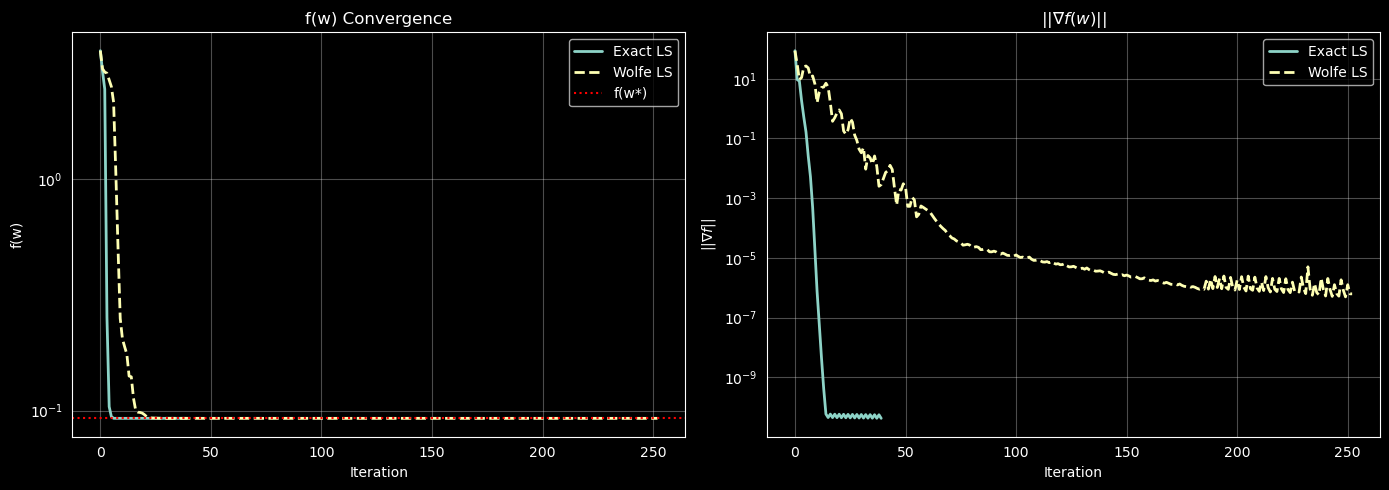

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(h_ex['f'], lw=2, label='Exact LS')
axes[0].semilogy(h_wo['f'], lw=2, ls='--', label='Wolfe LS')
axes[0].axhline(f_star, color='r', ls=':', label='f(w*)')
axes[0].set(xlabel='Iteration', ylabel='f(w)', title='f(w) Convergence')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].semilogy(h_ex['grad_norm'], lw=2, label='Exact LS')
axes[1].semilogy(h_wo['grad_norm'], lw=2, ls='--', label='Wolfe LS')
axes[1].set(xlabel='Iteration', ylabel=r"$||\nabla f||$", title=r"$||\nabla f(w)||$")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Effect of the `m_history` memory parameter
* **Stability and Optimality ($\overline{m} \ge 10$):** For $m=10, 20$, and $40$, the algorithm converges identically and very rapidly (in just **14 iterations**), achieving excellent precision (||w-w*|| = **5.51e-12**). This confirms what is reported in the literature: moderate memory values (between 3 and 20) often produce satisfactory results. Beyond the threshold of $m=10$, adding further memory does not improve convergence, but unnecessarily increases the computational cost per iteration.
* **The Numerical Anomaly ($m=5$):** The most interesting data point is the anomalous peak at **458 iterations** for $m=5$ (clearly visible as a dense oscillation in the chart). Because the real data contains correlated features, the shape of the loss function is a narrow and elongated valley. In this specific geometric landscape, a memory "window" of exactly 5 vectors ends up building an unbalanced Hessian approximation (ill-conditioned Hessian approximation), pushing the descent direction along sub-optimal zigzag trajectories from which the algorithm struggles to recover.
* **Under-approximation ($m=3$):** With only 3 vectors, the iterations rise to **33**. The memory is too short to accurately capture the full inverse Hessian, so the method approaches the behavior of simple gradient descent, slowing down convergence but avoiding the geometric trap that $m=5$ fell into.

**Conclusion:** For the ML-CUP dataset, setting $\overline{m} = 10$ represents the ideal "sweet spot" between low memory consumption, minimum cost per iteration, and maximum convergence stability.


In [6]:
results_mem = {}
for mh in [3, 5, 10, 20, 40]:
    w_m, h_m, t_m = lbfgs_optimize(
        X, y, lam, m_history=mh, tol=1e-12,
        tol_type='relative', line_search='exact', verbose=False)
    results_mem[mh] = h_m
    print(f"  m_history={mh:3d}  iter={len(h_m['f'])-1:4d}  "
          f"||w-w*||={np.linalg.norm(w_m-w_star):.2e}  t={t_m:.6f}s")

  m_history=  3  iter=  33  ||w-w*||=9.66e-11  t=0.000000s
  m_history=  5  iter= 458  ||w-w*||=9.72e-11  t=0.010010s
  m_history= 10  iter=  14  ||w-w*||=5.51e-12  t=0.000998s
  m_history= 20  iter=  14  ||w-w*||=5.51e-12  t=0.000000s
  m_history= 40  iter=  14  ||w-w*||=5.51e-12  t=0.001000s


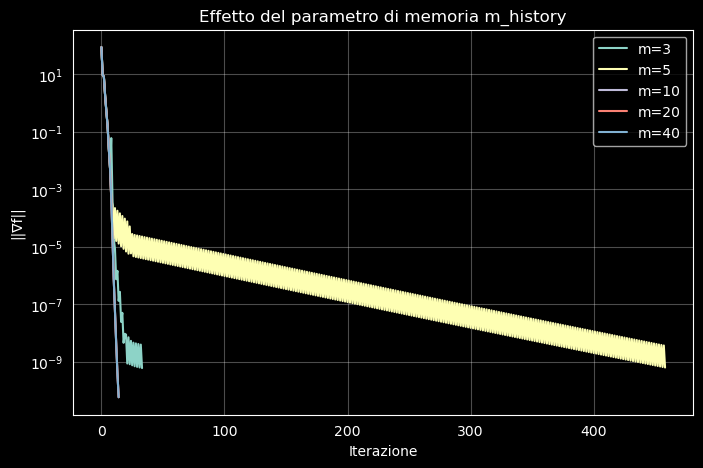

In [7]:
plt.figure(figsize=(8, 5))
for mh, h in results_mem.items():
    plt.semilogy(h['grad_norm'], label=f'm={mh}')
plt.xlabel('Iterazione'); plt.ylabel('||∇f||')
plt.title('Effetto del parametro di memoria m_history')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Effect of $\lambda$ (Conditioning)
The tests conducted by varying the regularization parameter $\lambda$ excellently confirm the theory regarding the conditioning of linear systems and the convergence of Quasi-Newton methods.

* **Relationship between $\lambda$ and the Condition Number ($\kappa$):** As predicted by the theoretical equation $\kappa(\hat{X}) = \frac{\sqrt{\lambda_1(XX^T) + \lambda^2}}{\lambda}$, as $\lambda$ increases, the condition number drops drastically. We go from a highly ill-conditioned problem for $\lambda$ = **0.0001** ($\kappa \approx$ **757629**) to a perfectly conditioned problem for $\lambda$ = **10000.0** ($\kappa$ = **1.0**).
* **Convergence Speed (Iterations):** The conditioning reflects directly on the geometry of the loss function $f(w)$. For large values of $\lambda$ ($\ge$ **100.0**), the term $\lambda^2 I_m$ dominates the Hessian. Geometrically, the "valleys" of the function become perfectly spherical basins: the gradient points exactly toward the minimum, and L-BFGS gets there in just **2 to 4 iterations**.

* **Robustness of the Exact Line Search:** The most impressive data point is the algorithm's resilience in ill-conditioned cases ($\lambda \le$ **1.0**). Despite a $\kappa$ exceeding **750,000** (where the contour lines are extremely narrow ellipses), the L-BFGS method combined with the *Exact Line Search* manages to converge in just **12 iterations**. This demonstrates the enormous advantage of calculating the step analytically on complex quadratic problems.
* **Computational Efficiency (L-BFGS vs. Exact Solver):** Looking at the execution times, our iterative algorithm (in Python) systematically beat the exact solver (BLAS/LAPACK in C). L-BFGS takes about **0.001s**, compared to the **~0.16s** of `np.linalg.solve`. This is because calculating and solving a dense system of size $m$ = **500** is significantly more expensive than running 12 lightweight iterations of vector-vector products, especially with a limited memory of $\overline{m}$ = **10**.
* **Final Precision:** Regularization helps stabilize the numerical solution. While for $\lambda$ = **0.0001** the error compared to the exact solution stops at $1.11 \times 10^{-5}$, with $\lambda$ = **10000.0** we reach an astounding precision of $4.48 \times 10^{-18}$, effectively exceeding standard machine precision.


In [8]:
results_lam = {}
for lam_val in [1e-4, 1e-2, 1.0, 1e2, 1e4]:
    w_l, h_l, t_l = lbfgs_optimize(
        X, y, lam_val, m_history=10, tol=1e-10,
        tol_type='relative', line_search='exact', verbose=False,
        max_iter=50000)
    w_star_l, f_star_l, tempo_star_l = solve_exact(X, y, lam_val)
    kappa_l = compute_condition_number(X, lam_val)
    results_lam[lam_val] = h_l
    print(f"  λ={lam_val:<8}  κ={kappa_l:>12.1f}  "
          f"iter={len(h_l['f'])-1:5d}  "
          f"||w-w*||={np.linalg.norm(w_l-w_star_l):.2e}  "
          f"t_LBFGS={t_l:.3f}s  t_exact={tempo_star_l:.5f}s")

  λ=0.0001    κ=    757629.4  iter=   12  ||w-w*||=1.11e-05  t_LBFGS=0.000s  t_exact=0.26862s
  λ=0.01      κ=      7574.6  iter=   12  ||w-w*||=1.48e-09  t_LBFGS=0.001s  t_exact=0.13346s
  λ=1.0       κ=        75.8  iter=   12  ||w-w*||=2.49e-10  t_LBFGS=0.000s  t_exact=0.15536s
  λ=100.0     κ=         1.3  iter=    4  ||w-w*||=3.07e-13  t_LBFGS=0.001s  t_exact=0.14810s
  λ=10000.0   κ=         1.0  iter=    2  ||w-w*||=4.48e-18  t_LBFGS=0.000s  t_exact=0.06594s


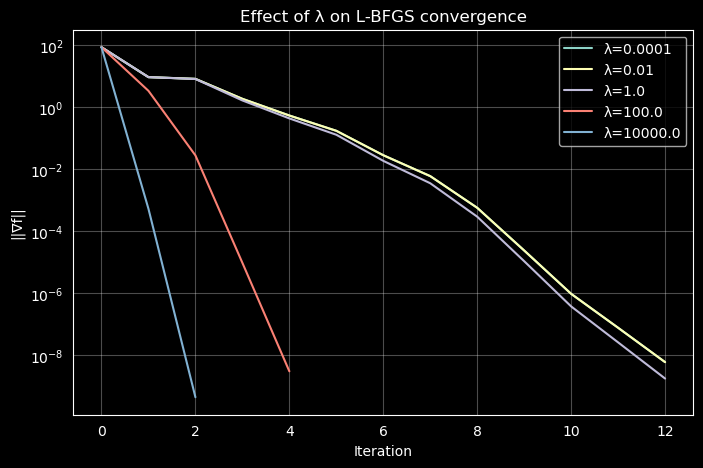

In [9]:
plt.figure(figsize=(8, 5))
for lam_val, h in results_lam.items():
    plt.semilogy(h['grad_norm'], label=f'λ={lam_val}')
plt.xlabel('Iteration'); plt.ylabel('||∇f||')
plt.title('Effect of λ on L-BFGS convergence')
plt.legend(); plt.grid(alpha=0.3)
plt.show()